In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

In [3]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [31]:
conditions = [
    df["grades"] >= 80,  # good
    df["grades"] >= 60,  # sufficient
]
choices = ["good", "sufficient"]

df["grade_category"] = np.select(conditions, choices, default="fail")

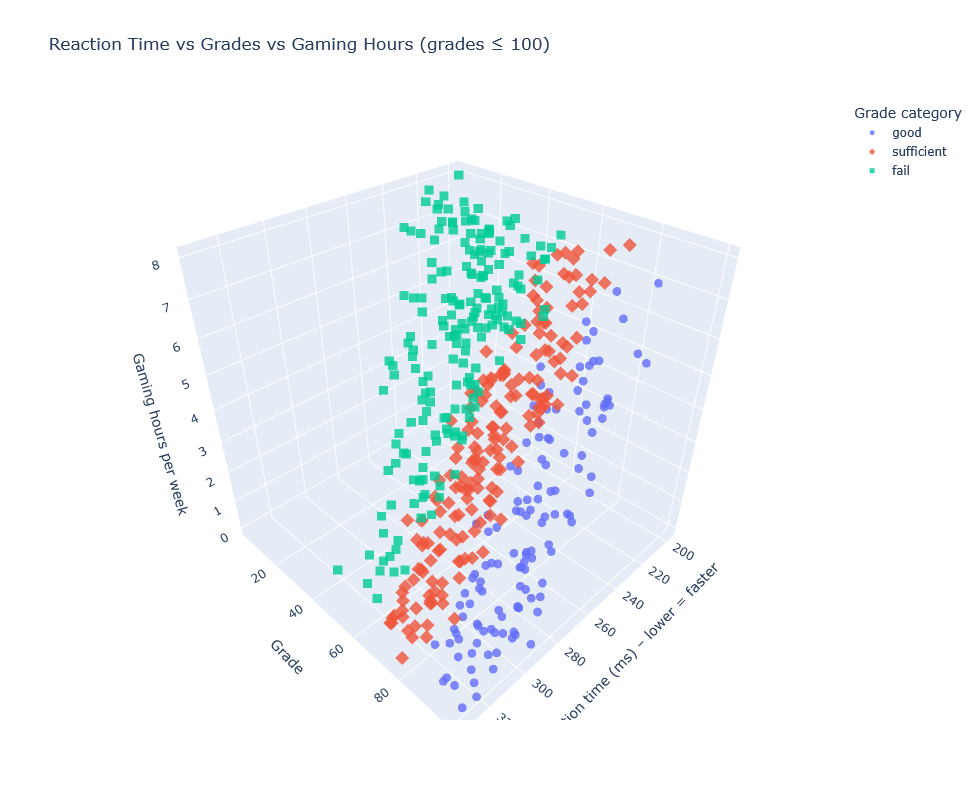

In [37]:
# 2. Create grade_category from grades
#   < 60      -> fail
#   60–79     -> sufficient
#   80+       -> good
df["grade_category"] = pd.cut(
    df["grades"],
    bins=[0, 60, 80, float("inf")],
    labels=["fail", "sufficient", "good"],
    right=False
)

# 3. Filter out unrealistic grades > 100
df_filtered = df[df["grades"] <= 100].copy()

# 4. Take a smaller sample if there are many rows (to make the plot clearer)
#    - If more than 500 rows, randomly sample 500
#    - Otherwise, use all filtered rows
if len(df_filtered) > 500:
    df_small = df_filtered.sample(n=500, random_state=0)
else:
    df_small = df_filtered.copy()

# 5. 3D scatter plot: Reaction time vs Grades vs Gaming hours
fig = px.scatter_3d(
    df_small,
    x="reaction_time_ms",
    y="grades",
    z="gaming_hours",
    color="grade_category",      # color by category
    symbol="grade_category",     # different marker symbols per category
    hover_data=[
        "student_id",
        "age",
        "gender",
        "gaming_hours",
        "study_hours",
        "reaction_time_ms",
        "grades",
        "grade_category",
    ],
    title="Reaction Time vs Grades vs Gaming Hours (grades ≤ 100)",
    width=1100,
    height=800,
)

# Make points easier to see
fig.update_traces(marker=dict(size=5, opacity=0.8))

# Improve axis labels and legend
fig.update_layout(
    scene=dict(
        xaxis_title="Reaction time (ms) – lower = faster",
        yaxis_title="Grade",
        zaxis_title="Gaming hours per week",
    ),
    legend_title_text="Grade category"
)

fig.show()